In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the CSV file into a DataFrame
df = pd.read_csv('losses.csv')

In [3]:
# Extract train and validation losses
epochs = df['Epoch']
train_loss = df['Train Loss']
val_loss = df['Validation Loss']

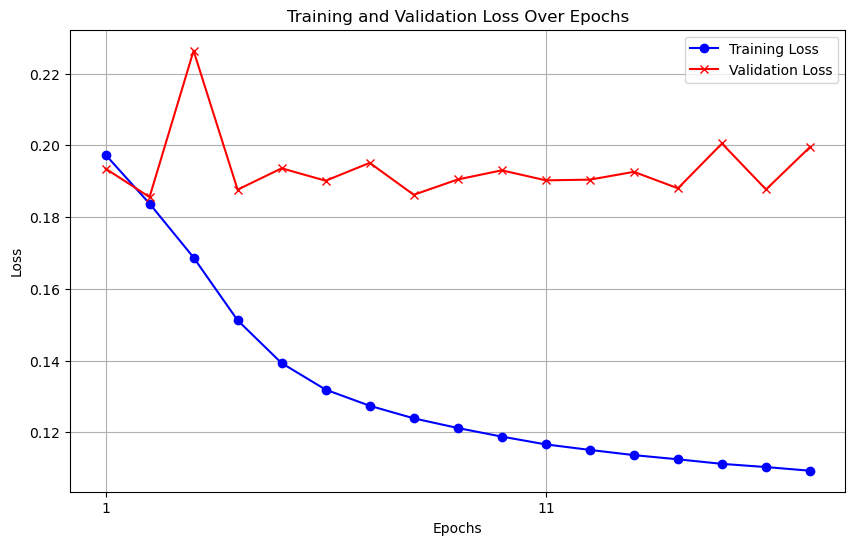

In [4]:
# Plotting the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss', color='b', linestyle='-', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', color='r', linestyle='-', marker='x')

# Adding title and labels
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.xticks(epochs[::10]) 

# Display the plot
plt.grid(True)
plt.show()

# If you want to save the plot, you can use:
# plt.savefig('training_validation_loss_plot.png')

In [ ]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from train_model import HiCDataset
from model import SeqNN

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = SeqNN()
model.load_state_dict(torch.load("/scratch1/smaruj/train_pytorch_akita/mouse_models/model_0_reference.pt", map_location=device))
model.to(device)
model.eval()

In [ ]:
import os

In [ ]:
data_dir = "/scratch1/smaruj/train_pytorch_akita/mouse"
test_fold = "fold0"

all_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".pt")]
test_files = [f for f in all_files if test_fold in f]

In [ ]:
# Load test dataset
test_dataset = HiCDataset(test_files)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
# Run model on test set
all_preds = []
all_targets = []
with torch.no_grad():
    for ohe_sequence, hic_vector in test_loader:
        ohe_sequence = ohe_sequence.to(device)
        hic_vector = hic_vector.to(device)
        
        outputs = model(ohe_sequence)
        all_preds.append(outputs.cpu())
        all_targets.append(hic_vector.cpu())

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_map(matrix, vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5):
    fig, axes = plt.subplots(1, 1, figsize=(width, height))

    sns.heatmap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes
    )

    plt.tight_layout()
    plt.show()
    

# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value


def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [ ]:
# Convert lists to tensors
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

In [ ]:
num_examples = 5
for i in range(num_examples):
    print("Example", i)
    print("True")
    plot_map(from_upper_triu(all_targets[i, :, :], matrix_len=512, num_diags=2))
    print("Prediction")
    plot_map(from_upper_triu(all_preds[i, :, :], matrix_len=512, num_diags=2))

In [ ]:
# Compute correlation efficiently, ignoring NaNs
pred_mean = torch.nanmean(all_preds, dim=0, keepdim=True)
target_mean = torch.nanmean(all_targets, dim=0, keepdim=True)

# numerator - covariance
num = torch.nansum((all_preds - pred_mean) * (all_targets - target_mean), dim=0)
# denumerator - sd
den = torch.sqrt(torch.nansum((all_preds - pred_mean) ** 2, dim=0) * torch.nansum((all_targets - target_mean) ** 2, dim=0))
correlations = num / den

In [ ]:
# Average correlation (ignoring NaNs)
avg_correlation = torch.nanmean(correlations).item()
print(f"Average Pearson correlation: {avg_correlation:.4f}")

In [ ]:
# Plot correlation distribution
sns.histplot(correlations.numpy().flatten(), bins=50, kde=True)
plt.xlabel("Pearson Correlation")
plt.ylabel("Frequency")
plt.title("Distribution of Pearson Correlations")
plt.show()